# JitGen Paper Artifacts (TARP figures 3–10)

This notebook generates all figures and tables for the JitGen article submitted to *Technology Audit and Production Reserves* (TARP).
It compares **Async (JitGen)** — incremental, streaming code execution — against **Sync** — traditional generate-then-execute — across 6 LLMs on the MBPP benchmark.

**Outputs:**
- `images/` — `fig-*.png` figures, 170 mm wide at 300 DPI, all text 14 pt Times New Roman (TARP requirements: no in-figure titles, all notation decoded in-figure, axis labels with units on every panel, grayscale-distinguishable)
- `tables/` — CSV summary tables

Figure numbering matches the TARP manuscript (`draft_tarp.md`); Figures 1–2 of the article are pseudocode and not generated here.

| Article figure | File | Content |
|---|---|---|
| Fig. 3 | fig-first-output-violin.png | Violin plots, time to first output (main figure) |
| Fig. 4 | fig-first-output-ecdf.png | ECDF of time to first output, per model |
| Fig. 5 | fig-delta-first-output-boxplot.png | Paired per-task Δ of time to first output |
| Fig. 6 | fig-execution-time-violin.png | Violin plots, total execution time |
| Fig. 7 | fig-speedup-ratio-barplot.png | Median speedup ratio per model |
| Fig. 8 | fig-correctness-barplot.png | Pass and correctness rates |
| Fig. 9 | fig-error-distribution.png | Run outcome counts by error category |
| Fig. 10 | fig-summary-heatmap.png | Overview heatmap of benchmark metrics |

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Paths ──────────────────────────────────────────────────────────────
RESULTS_DIR = Path("../evaluation/results")
IMAGES_DIR = Path("images")
TABLES_DIR = Path("tables")
IMAGES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

# ── TARP figure format ─────────────────────────────────────────────────
# 170 mm printed width (A4 minus 20 mm margins), inserted into Word at 100%
# scale; height ≤ 200 mm; PNG ≥ 300 dpi; ALL in-figure text 14 pt Times New
# Roman; no in-figure titles (captions live in the manuscript).
MM = 1 / 25.4
FIG_W = 170 * MM            # 6.693 in
FIG_H_MAX = 200 * MM        # 7.874 in
DPI = 300

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size": 14, "axes.labelsize": 14, "xtick.labelsize": 14,
    "ytick.labelsize": 14, "legend.fontsize": 14, "axes.titlesize": 14,
    "legend.title_fontsize": 14,
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.5,
    "grid.color": "#d9d9d9",
    "grid.linewidth": 0.6,
    "figure.dpi": 100,
    "savefig.dpi": DPI,
})

# Exact series names used in the manuscript; high-contrast color pair plus
# hatch/linestyle so the pair survives grayscale print.
STRATEGY_LABELS = {"Async": "Async (JitGen)", "Sync": "Sync"}
STRATEGIES = ["Async (JitGen)", "Sync"]
PALETTE = {"Async (JitGen)": "#1f77b4", "Sync": "#d62728"}
HATCHES = {"Async (JitGen)": None, "Sync": "//"}
LINESTYLES = {"Async (JitGen)": "-", "Sync": "--"}

MODEL_LABELS = {
    "gemma3_latest": "Gemma 3",
    "llama3_2_latest": "Llama 3.2",
    "phi4_latest": "Phi 4",
    "gpt-oss_20b": "GPT-OSS 20B",
    "qwen3-coder_30b": "Qwen3-Coder 30B",
    "xingyaow__codeact-agent-mistral": "CodeAct-Mistral",
}
MODEL_ORDER = ["Gemma 3", "Llama 3.2", "Phi 4", "GPT-OSS 20B", "Qwen3-Coder 30B", "CodeAct-Mistral"]


def new_fig(height_mm: float, nrows: int = 1, ncols: int = 1, **kwargs):
    """Figure at the exact TARP width (170 mm) and the given height in mm."""
    assert height_mm <= 200, "TARP: figure must fit one A4 page incl. caption"
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(FIG_W, height_mm * MM),
        constrained_layout=True, **kwargs,
    )
    for ax in np.atleast_1d(axes).ravel():
        ax.set_axisbelow(True)
    return fig, axes


def save_fig(fig, name: str) -> None:
    """Save without tight-cropping so the pixel width stays exactly 170 mm × DPI."""
    path = IMAGES_DIR / name
    fig.savefig(path, dpi=DPI, facecolor="white")
    print(f"Saved {path} ({path.stat().st_size / 2**20:.2f} MB)")


def label_panel(ax, letter: str) -> None:
    """Italic 14 pt panel letter (a, b, …) in the top-left corner."""
    ax.text(0.02, 0.97, letter, transform=ax.transAxes,
            ha="left", va="top", fontsize=14, fontstyle="italic")


print("Setup complete")

Setup complete


In [2]:
def _extract_model_key(filename_stem: str) -> str:
    """Extract model key from filename by matching against known MODEL_LABELS keys.

    Handles variable-length model names like 'llama3_2_latest' (3 tokens)
    vs 'gemma3_latest' (2 tokens).
    """
    for n_tokens in range(4, 0, -1):  # try longest match first
        parts = filename_stem.split("_")
        candidate = "_".join(parts[:n_tokens])
        if candidate in MODEL_LABELS:
            return candidate
    # Fallback: first two tokens
    return "_".join(filename_stem.split("_")[:2])


def load_benchmark_df(results_dir: Path) -> pd.DataFrame:
    """Load all benchmark CSVs into a single DataFrame with ModelName and Algorithm columns."""
    frames = []
    for csv_path in sorted(results_dir.glob("*.csv")):
        model_key = _extract_model_key(csv_path.stem)
        algorithm = "Async" if "async" in csv_path.stem else "Sync"
        frame = pd.read_csv(csv_path)
        frame["ModelName"] = model_key
        frame["Algorithm"] = algorithm
        frames.append(frame)
    df_all = pd.concat(frames, ignore_index=True)
    df_all["ModelLabel"] = df_all["ModelName"].map(MODEL_LABELS)
    df_all["Strategy"] = df_all["Algorithm"].map(STRATEGY_LABELS)
    return df_all


df = load_benchmark_df(RESULTS_DIR)
assert not df["ModelLabel"].isna().any(), "Unmapped model key — check MODEL_LABELS"

# Build paired delta DataFrame — each RowID may appear multiple times (multiple test cases)
# Use cumcount within (Model, Algorithm, RowID) to create a sub-index for proper pairing
paired_frames = []
for model in df["ModelLabel"].unique():
    df_model = df[df["ModelLabel"] == model].copy()
    df_model["SubIdx"] = df_model.groupby(["Algorithm", "RowID"]).cumcount()

    df_async = df_model[df_model["Algorithm"] == "Async"].copy()
    df_sync = df_model[df_model["Algorithm"] == "Sync"].copy()

    merged = df_async.merge(
        df_sync,
        on=["RowID", "SubIdx"],
        suffixes=("_async", "_sync"),
        how="inner",
    )
    paired = pd.DataFrame({
        "RowID": merged["RowID"],
        "ModelLabel": model,
        "AsyncExecTime": merged["ExecutionTime_async"].values,
        "SyncExecTime": merged["ExecutionTime_sync"].values,
        "AsyncFirstOutput": merged["FirstOutput_async"].values,
        "SyncFirstOutput": merged["FirstOutput_sync"].values,
        "AsyncCorrect": merged["CorrectOutput_async"].values,
        "SyncCorrect": merged["CorrectOutput_sync"].values,
        "AsyncError": merged["ErrorOccurred_async"].values,
        "SyncError": merged["ErrorOccurred_sync"].values,
    })
    paired["DeltaExecTime"] = paired["AsyncExecTime"] - paired["SyncExecTime"]
    paired["DeltaFirstOutput"] = paired["AsyncFirstOutput"] - paired["SyncFirstOutput"]
    paired["SpeedupFirstOutput"] = paired["SyncFirstOutput"] / paired["AsyncFirstOutput"]
    paired_frames.append(paired)

df_paired = pd.concat(paired_frames, ignore_index=True)

print(f"Loaded {len(df)} rows from {df['ModelName'].nunique()} models")
print(f"Paired observations: {len(df_paired)}")
print(f"Models: {', '.join(df['ModelLabel'].dropna().unique())}")
print(f"\nPer-model row counts:")
print(df.groupby(["ModelLabel", "Algorithm"]).size().unstack(fill_value=0))
df.head()

Loaded 1356 rows from 6 models
Paired observations: 678
Models: Gemma 3, GPT-OSS 20B, Llama 3.2, Phi 4, Qwen3-Coder 30B, CodeAct-Mistral

Per-model row counts:
Algorithm        Async  Sync
ModelLabel                  
CodeAct-Mistral    113   113
GPT-OSS 20B        113   113
Gemma 3            113   113
Llama 3.2          113   113
Phi 4              113   113
Qwen3-Coder 30B    113   113


,RowID,ErrorOccurred,ExecutionOutput,HasTimedOut,ExecutionError,ExecutionTime,ExpectedOutput,ActualOutput,CorrectOutput,FirstOutput,ModelName,Algorithm,ModelLabel,Strategy
0,511,False,192\r\n,False,NaN,2.470870,15,192,False,1.985238,gemma3_latest,Async,Gemma 3,Async (JitGen)
1,511,False,7\r\n,False,NaN,2.237782,2,7,False,1.992164,gemma3_latest,Async,Gemma 3,Async (JitGen)
2,512,False,"{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}\r\n",False,NaN,2.958128,"{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}","{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}",True,2.128772,gemma3_latest,Async,Gemma 3,Async (JitGen)
3,512,False,"{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}\r\n",False,NaN,2.731242,"{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}","{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}",True,2.124765,gemma3_latest,Async,Gemma 3,Async (JitGen)
4,513,False,"[7, 'PF', 8, 'PF', 9, 'PF', 10, 'PF']\r\n",False,NaN,2.308076,"[7, 'PF', 8, 'PF', 9, 'PF', 10, 'PF']","[7, 'PF', 8, 'PF', 9, 'PF', 10, 'PF']",True,2.008135,gemma3_latest,Async,Gemma 3,Async (JitGen)


In [3]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 1 — Summary Statistics (Execution Time & First Output)
# ══════════════════════════════════════════════════════════════════════
summary = (
    df.groupby(["ModelLabel", "Algorithm"])
    .agg(
        Count=("ExecutionTime", "size"),
        ExecTime_Mean=("ExecutionTime", "mean"),
        ExecTime_Median=("ExecutionTime", "median"),
        ExecTime_Std=("ExecutionTime", "std"),
        FirstOutput_Mean=("FirstOutput", "mean"),
        FirstOutput_Median=("FirstOutput", "median"),
        FirstOutput_Std=("FirstOutput", "std"),
    )
    .round(3)
)
summary.to_csv(TABLES_DIR / "summary_statistics.csv")
print("Saved tables/summary_statistics.csv")
summary

Saved tables/summary_statistics.csv


Count  ExecTime_Mean  ExecTime_Median  \
ModelLabel      Algorithm                                          
CodeAct-Mistral Async        113          2.926            2.802   
                Sync         113         10.490           10.074   
GPT-OSS 20B     Async        113         20.523            8.295   
                Sync         113         20.464            8.301   
Gemma 3         Async        113          2.516            2.442   
                Sync         113          2.565            2.486   
Llama 3.2       Async        113          2.101            1.969   
                Sync         113          1.992            1.930   
Phi 4           Async        113          3.969            3.864   
                Sync         113          3.886            3.884   
Qwen3-Coder 30B Async        113          6.232            4.696   
                Sync         113          6.100            4.642   

                           ExecTime_Std  FirstOutput_Mean  FirstOutput_Median  \
ModelLabel      Algorithm                                                       
CodeAct-Mistral Async             0.719             2.163               2.117   
                Sync              4.084            10.466              10.027   
GPT-OSS 20B     Async            32.635            20.179               7.958   
                Sync             32.636            20.464               8.300   
Gemma 3         Async             0.444             2.081               2.055   
                Sync              0.327             2.565               2.485   
Llama 3.2       Async             0.778             1.821               1.659   
                Sync              0.231             1.992               1.930   
Phi 4           Async             0.983             3.395               3.263   
                Sync              0.805             3.886               3.884   
Qwen3-Coder 30B Async             4.852             5.232               4.027   
                Sync              4.019             6.100               4.642   

                           FirstOutput_Std  
ModelLabel      Algorithm                   
CodeAct-Mistral Async                0.286  
                Sync                 4.085  
GPT-OSS 20B     Async               32.730  
                Sync                32.636  
Gemma 3         Async                0.273  
                Sync                 0.327  
Llama 3.2       Async                0.765  
                Sync                 0.231  
Phi 4           Async                0.823  
                Sync                 0.805  
Qwen3-Coder 30B Async                2.967  
                Sync                 4.019

In [4]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 2 — Pass Rate, Correctness Rate, Timeout Rate
# ══════════════════════════════════════════════════════════════════════
pass_correct = (
    df.groupby(["ModelLabel", "Algorithm"])
    .agg(
        Count=("RowID", "size"),
        PassRate=("ErrorOccurred", lambda x: (1 - x.mean()) * 100),
        CorrectnessRate=("CorrectOutput", lambda x: x.mean() * 100),
        TimeoutRate=("HasTimedOut", lambda x: x.mean() * 100),
    )
    .round(2)
)
pass_correct.to_csv(TABLES_DIR / "pass_correctness.csv")
print("Saved tables/pass_correctness.csv")
pass_correct

Saved tables/pass_correctness.csv


Count  PassRate  CorrectnessRate  TimeoutRate
ModelLabel      Algorithm                                               
CodeAct-Mistral Async        113     86.73            41.59          0.0
                Sync         113     86.73            41.59          0.0
GPT-OSS 20B     Async        113    100.00            58.41          0.0
                Sync         113    100.00            58.41          0.0
Gemma 3         Async        113     98.23            54.87          0.0
                Sync         113     98.23            54.87          0.0
Llama 3.2       Async        113     85.84            30.97          0.0
                Sync         113     86.73            30.97          0.0
Phi 4           Async        113     99.12            71.68          0.0
                Sync         113     99.12            71.68          0.0
Qwen3-Coder 30B Async        113     99.12            77.88          0.0
                Sync         113     99.12            77.88          0.0

In [5]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 3 — Statistical Tests (Wilcoxon signed-rank, paired)
# ══════════════════════════════════════════════════════════════════════
def rank_biserial(w_stat, n):
    """Rank-biserial correlation as effect size for Wilcoxon test."""
    return 1 - (2 * w_stat) / (n * (n + 1) / 2)


test_rows = []
n_tests = 0
for model in MODEL_ORDER:
    mp = df_paired[df_paired["ModelLabel"] == model]
    for metric, col in [("ExecutionTime", "DeltaExecTime"), ("FirstOutput", "DeltaFirstOutput")]:
        deltas = mp[col].dropna()
        # Remove zero differences (Wilcoxon cannot handle them)
        deltas_nz = deltas[deltas != 0]
        n = len(deltas_nz)
        if n < 10:
            test_rows.append({
                "Model": model, "Metric": metric,
                "N": n, "MeanDelta": deltas.mean(), "MedianDelta": deltas.median(),
                "W": np.nan, "p_value": np.nan, "p_corrected": np.nan,
                "EffectSize_r": np.nan, "Significant": "N/A (n<10)",
            })
            n_tests += 1
            continue
        w, p = stats.wilcoxon(deltas_nz, alternative="two-sided")
        r = rank_biserial(w, n)
        n_tests += 1
        test_rows.append({
            "Model": model, "Metric": metric,
            "N": n, "MeanDelta": round(deltas.mean(), 4),
            "MedianDelta": round(deltas.median(), 4),
            "W": w, "p_value": p, "p_corrected": None,
            "EffectSize_r": round(r, 4), "Significant": None,
        })

# Bonferroni correction
alpha = 0.05
for row in test_rows:
    if row["p_value"] is not None and not np.isnan(row["p_value"]):
        row["p_corrected"] = min(row["p_value"] * n_tests, 1.0)
        row["Significant"] = "Yes" if row["p_corrected"] < alpha else "No"

df_tests = pd.DataFrame(test_rows)
df_tests.to_csv(TABLES_DIR / "statistical_tests.csv", index=False)
print("Saved tables/statistical_tests.csv")
df_tests

Saved tables/statistical_tests.csv


,Model,Metric,N,MeanDelta,MedianDelta,W,p_value,p_corrected,EffectSize_r,Significant
0,Gemma 3,ExecutionTime,113,-0.0488,-0.0522,803.0,4.336367e-12,5.203641e-11,0.7507,Yes
1,Gemma 3,FirstOutput,113,-0.4840,-0.4455,8.0,3.470809e-20,4.164970e-19,0.9975,Yes
2,Llama 3.2,ExecutionTime,113,0.1086,0.0087,2222.0,4.229106e-03,5.074928e-02,0.3100,No
3,Llama 3.2,FirstOutput,113,-0.1713,-0.2139,248.0,1.655154e-17,1.986185e-16,0.9230,Yes
4,Phi 4,ExecutionTime,113,0.0834,0.0153,1715.0,1.610371e-05,1.932446e-04,0.4675,Yes
5,Phi 4,FirstOutput,113,-0.4903,-0.4470,221.0,8.465314e-18,1.015838e-16,0.9314,Yes
6,GPT-OSS 20B,ExecutionTime,113,0.0587,0.0015,2763.0,1.899705e-01,1.000000e+00,0.1421,No
7,GPT-OSS 20B,FirstOutput,113,-0.2851,-0.2887,653.0,1.902307e-13,2.282768e-12,0.7972,Yes
8,Qwen3-Coder 30B,ExecutionTime,113,0.1321,0.0037,2792.0,2.196025e-01,1.000000e+00,0.1331,No
9,Qwen3-Coder 30B,FirstOutput,113,-0.8680,-0.4104,225.0,9.352873e-18,1.122345e-16,0.9301,Yes


In [6]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 4 — Error Type Breakdown
# ══════════════════════════════════════════════════════════════════════
import re

def classify_error(row):
    if not row["ErrorOccurred"]:
        return "Success"
    if row["HasTimedOut"]:
        return "Timeout"
    err = str(row.get("ExecutionError", ""))
    if "input()" in err or "input() function" in err:
        return "Disabled input()"
    if "TypeError" in err or "not callable" in err or "not iterable" in err:
        return "TypeError"
    if "IndexError" in err or "not subscriptable" in err or "pop from empty" in err:
        return "IndexError"
    if "NameError" in err:
        return "NameError"
    if "SyntaxError" in err:
        return "SyntaxError"
    if "ValueError" in err:
        return "ValueError"
    if "AttributeError" in err:
        return "AttributeError"
    if err.strip():
        return "Other Error"
    return "Unknown Error"

df["ErrorCategory"] = df.apply(classify_error, axis=1)

error_breakdown = (
    df.groupby(["ModelLabel", "Algorithm", "ErrorCategory"])
    .size()
    .reset_index(name="Count")
)
error_pivot = error_breakdown.pivot_table(
    index=["ModelLabel", "Algorithm"],
    columns="ErrorCategory",
    values="Count",
    fill_value=0,
)
error_pivot.to_csv(TABLES_DIR / "error_breakdown.csv")
print("Saved tables/error_breakdown.csv")
error_pivot

Saved tables/error_breakdown.csv


ErrorCategory              Disabled input()  IndexError  Other Error  Success  \
ModelLabel      Algorithm                                                       
CodeAct-Mistral Async                   0.0         0.0         14.0     98.0   
                Sync                    0.0         0.0         14.0     98.0   
GPT-OSS 20B     Async                   0.0         0.0          0.0    113.0   
                Sync                    0.0         0.0          0.0    113.0   
Gemma 3         Async                   0.0         0.0          2.0    111.0   
                Sync                    0.0         0.0          2.0    111.0   
Llama 3.2       Async                   5.0         2.0          6.0     97.0   
                Sync                    5.0         2.0          5.0     98.0   
Phi 4           Async                   0.0         0.0          1.0    112.0   
                Sync                    0.0         0.0          1.0    112.0   
Qwen3-Coder 30B Async                   0.0         0.0          1.0    112.0   
                Sync                    0.0         0.0          1.0    112.0   

ErrorCategory              TypeError  
ModelLabel      Algorithm             
CodeAct-Mistral Async            1.0  
                Sync             1.0  
GPT-OSS 20B     Async            0.0  
                Sync             0.0  
Gemma 3         Async            0.0  
                Sync             0.0  
Llama 3.2       Async            3.0  
                Sync             3.0  
Phi 4           Async            0.0  
                Sync             0.0  
Qwen3-Coder 30B Async            0.0  
                Sync             0.0

Saved images\fig-first-output-violin.png (0.24 MB)


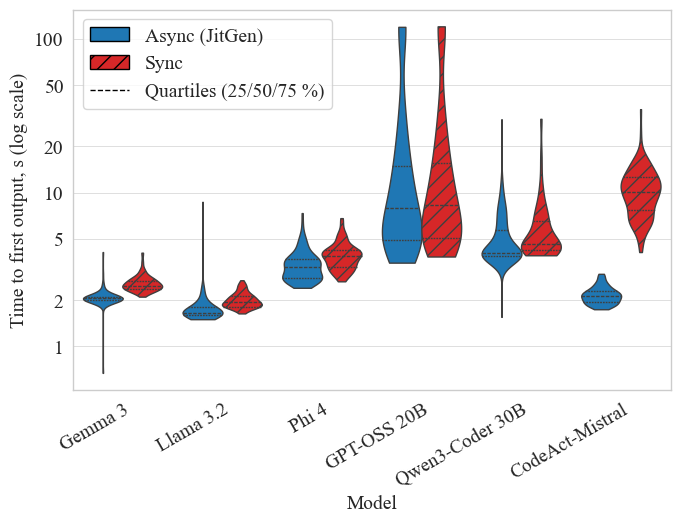

In [7]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 3 — fig-first-output-violin.png (journal main figure)
# Time to first output by model and strategy, grouped violins, log Y
# ══════════════════════════════════════════════════════════════════════
from matplotlib.colors import to_rgba


def strategy_violin(y_col: str, y_label: str, filename: str) -> None:
    """Grouped Async/Sync violins per model — shared by Figs 3 and 6."""
    fig, ax = new_fig(130)
    sns.violinplot(
        data=df, x="ModelLabel", y=y_col, hue="Strategy",
        order=MODEL_ORDER, hue_order=STRATEGIES, palette=PALETTE,
        saturation=1, inner="quartile", cut=0, density_norm="width",
        linewidth=1.0, log_scale=True, ax=ax,
    )
    # Hatch the Sync violin bodies so the pair survives grayscale print
    sync_rgb = to_rgba(PALETTE["Sync"])[:3]
    for coll in ax.collections:
        fc = coll.get_facecolor()
        if len(fc) and np.allclose(fc[0][:3], sync_rgb, atol=0.02):
            coll.set_hatch(HATCHES["Sync"])

    ax.set_xlabel("Model")
    ax.set_ylabel(y_label)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1, 2, 5)))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    if ax.get_legend() is not None:
        ax.get_legend().remove()
    handles = [
        Patch(facecolor=PALETTE[s], hatch=HATCHES[s], edgecolor="black",
              linewidth=1.0, label=s)
        for s in STRATEGIES
    ]
    handles.append(Line2D([0], [0], color="black", linestyle="--",
                          linewidth=1.0, label="Quartiles (25/50/75 %)"))
    ax.legend(handles=handles, loc="upper left", frameon=True)

    save_fig(fig, filename)
    plt.show()


strategy_violin("FirstOutput", "Time to first output, s (log scale)",
                "fig-first-output-violin.png")

Saved images\fig-first-output-ecdf.png (0.25 MB)


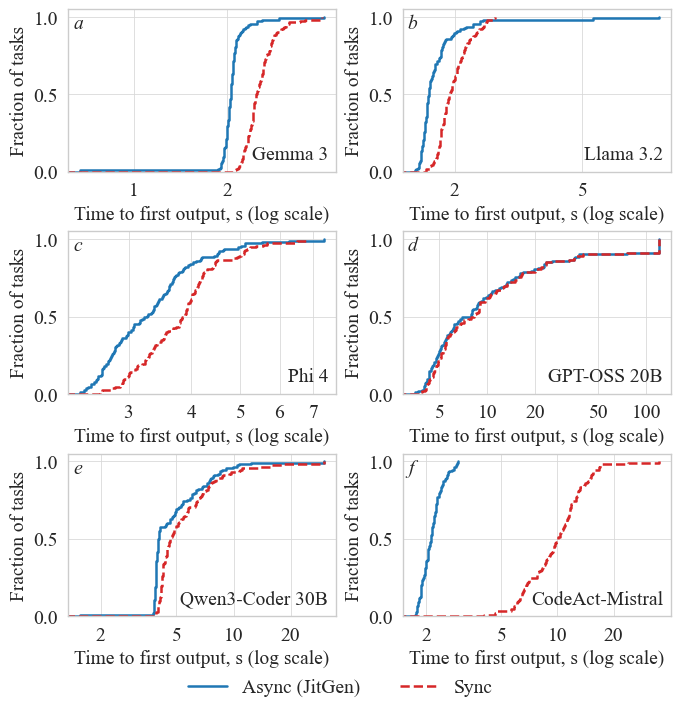

In [8]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 4 — fig-first-output-ecdf.png
# ECDF of time to first output, one model per panel (a–f)
# ══════════════════════════════════════════════════════════════════════
PANEL_LETTERS = ["a", "b", "c", "d", "e", "f"]

fig, axes = new_fig(180, nrows=3, ncols=2)

for ax, letter, model in zip(axes.ravel(), PANEL_LETTERS, MODEL_ORDER):
    for strategy in STRATEGIES:
        subset = df[(df["ModelLabel"] == model) & (df["Strategy"] == strategy)]["FirstOutput"]
        sns.ecdfplot(data=subset, ax=ax, color=PALETTE[strategy],
                     linestyle=LINESTYLES[strategy], linewidth=1.8)
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1, 2, 5)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel("Time to first output, s (log scale)")
    ax.set_ylabel("Fraction of tasks")
    ax.set_ylim(0, 1.05)
    label_panel(ax, letter)
    ax.text(0.97, 0.05, model, transform=ax.transAxes,
            ha="right", va="bottom", fontsize=14)

handles = [
    Line2D([0], [0], color=PALETTE[s], linestyle=LINESTYLES[s],
           linewidth=1.8, label=s)
    for s in STRATEGIES
]
fig.legend(handles=handles, loc="outside lower center", ncols=2, frameon=False)

save_fig(fig, "fig-first-output-ecdf.png")
plt.show()

Saved images\fig-delta-first-output-boxplot.png (0.18 MB)


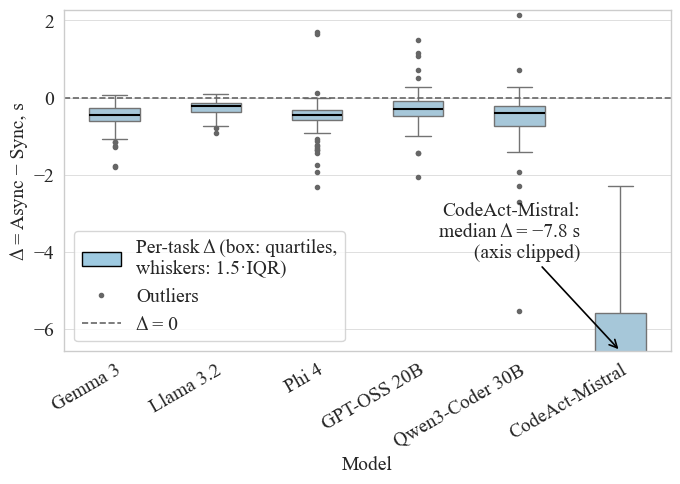

In [9]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 5 — fig-delta-first-output-boxplot.png
# Paired per-task Δ of time to first output (Async − Sync)
# ══════════════════════════════════════════════════════════════════════
BOX_FACE = "#9ecae1"
OUTLIER_GRAY = "#666666"

fig, ax = new_fig(120)
sns.boxplot(
    data=df_paired, x="ModelLabel", y="DeltaFirstOutput", order=MODEL_ORDER,
    color=BOX_FACE, width=0.5, ax=ax,
    flierprops=dict(marker="o", markersize=3, markerfacecolor=OUTLIER_GRAY,
                    markeredgecolor=OUTLIER_GRAY),
    medianprops=dict(color="black", linewidth=1.5),
)
ax.axhline(0, color=OUTLIER_GRAY, linestyle="--", linewidth=1.2)

# CodeAct-Mistral (median ≈ −8 s) would compress the other boxes on a full
# scale — clip the axis to the non-CodeAct range and annotate its median.
others = df_paired.loc[df_paired["ModelLabel"] != "CodeAct-Mistral", "DeltaFirstOutput"]
y_lo = float(others.quantile(0.005)) - 0.5
y_hi = float(others.quantile(0.995)) + 0.5
ax.set_ylim(y_lo, y_hi)

codeact_median = df_paired.loc[
    df_paired["ModelLabel"] == "CodeAct-Mistral", "DeltaFirstOutput"
].median()
median_str = f"{codeact_median:.1f}".replace("-", "−")  # typographic minus
codeact_x = MODEL_ORDER.index("CodeAct-Mistral")
ax.annotate(
    f"CodeAct-Mistral:\nmedian Δ = {median_str} s\n(axis clipped)",
    xy=(codeact_x, y_lo), xytext=(codeact_x - 0.4, y_lo + 0.35 * (y_hi - y_lo)),
    ha="right", va="center", fontsize=14,
    arrowprops=dict(arrowstyle="->", color="black", linewidth=1.2),
)

ax.set_xlabel("Model")
ax.set_ylabel("Δ = Async − Sync, s")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

handles = [
    Patch(facecolor=BOX_FACE, edgecolor="black", linewidth=1.0,
          label="Per-task Δ (box: quartiles,\nwhiskers: 1.5·IQR)"),
    Line2D([0], [0], marker="o", color="none", markersize=3,
           markerfacecolor=OUTLIER_GRAY, markeredgecolor=OUTLIER_GRAY,
           label="Outliers"),
    Line2D([0], [0], color=OUTLIER_GRAY, linestyle="--", linewidth=1.2,
           label="Δ = 0"),
]
ax.legend(handles=handles, loc="lower left", frameon=True)

save_fig(fig, "fig-delta-first-output-boxplot.png")
plt.show()

Saved images\fig-execution-time-violin.png (0.25 MB)


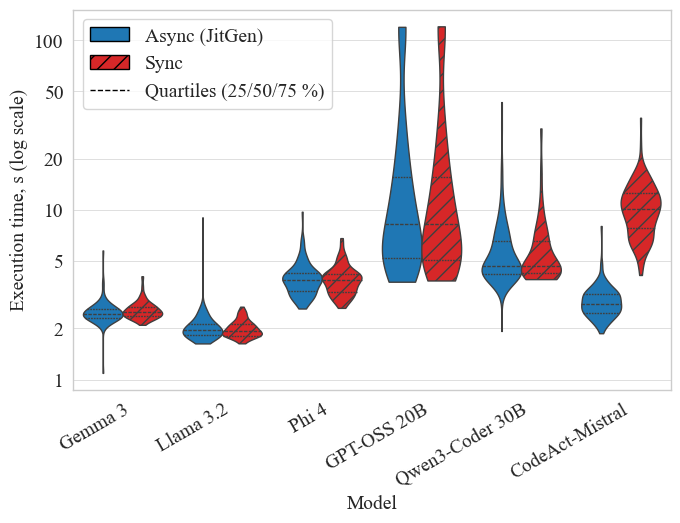

In [10]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 6 — fig-execution-time-violin.png
# Total execution time, same layout and log-Y decision as Fig. 3
# ══════════════════════════════════════════════════════════════════════
strategy_violin("ExecutionTime", "Execution time, s (log scale)",
                "fig-execution-time-violin.png")

Saved images\fig-speedup-ratio-barplot.png (0.18 MB)


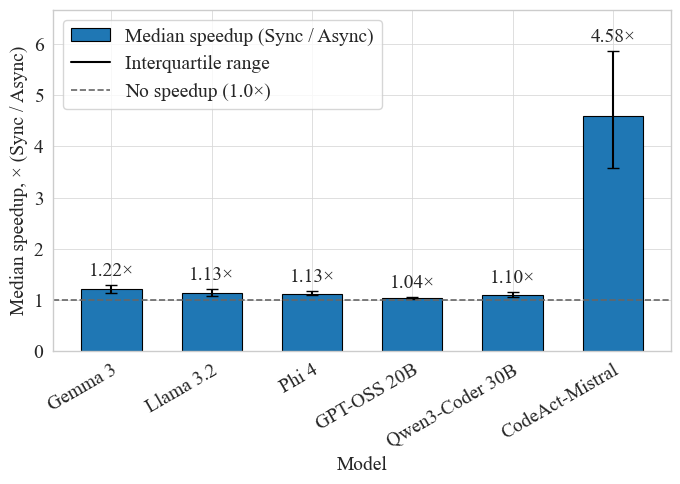

In [11]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 7 — fig-speedup-ratio-barplot.png
# Median first-output speedup ratio (Sync / Async) per model
# ══════════════════════════════════════════════════════════════════════
speedup_stats = (
    df_paired.groupby("ModelLabel")["SpeedupFirstOutput"]
    .agg(Median="median",
         Q1=lambda x: x.quantile(0.25),
         Q3=lambda x: x.quantile(0.75))
    .reindex(MODEL_ORDER)
)

fig, ax = new_fig(120)
x = np.arange(len(MODEL_ORDER))
bars = ax.bar(x, speedup_stats["Median"], width=0.6,
              color=PALETTE["Async (JitGen)"], edgecolor="black", linewidth=0.8)
ax.errorbar(x, speedup_stats["Median"],
            yerr=[speedup_stats["Median"] - speedup_stats["Q1"],
                  speedup_stats["Q3"] - speedup_stats["Median"]],
            fmt="none", ecolor="black", capsize=4, linewidth=1.5)
ax.axhline(1.0, color="#666666", linestyle="--", linewidth=1.2)

for xi, (median, q3) in enumerate(zip(speedup_stats["Median"], speedup_stats["Q3"])):
    ax.text(xi, max(median, q3) + 0.10, f"{median:.2f}×",
            ha="center", va="bottom", fontsize=14)

ax.set_xlabel("Model")
ax.set_ylabel("Median speedup, × (Sync / Async)")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha="right", rotation_mode="anchor")
ax.set_ylim(0, float(speedup_stats["Q3"].max()) + 0.8)

handles = [
    Patch(facecolor=PALETTE["Async (JitGen)"], edgecolor="black", linewidth=0.8,
          label="Median speedup (Sync / Async)"),
    Line2D([0], [0], color="black", linewidth=1.5, label="Interquartile range"),
    Line2D([0], [0], color="#666666", linestyle="--", linewidth=1.2,
           label="No speedup (1.0×)"),
]
ax.legend(handles=handles, loc="upper left", frameon=True)

save_fig(fig, "fig-speedup-ratio-barplot.png")
plt.show()

Saved images\fig-correctness-barplot.png (0.26 MB)


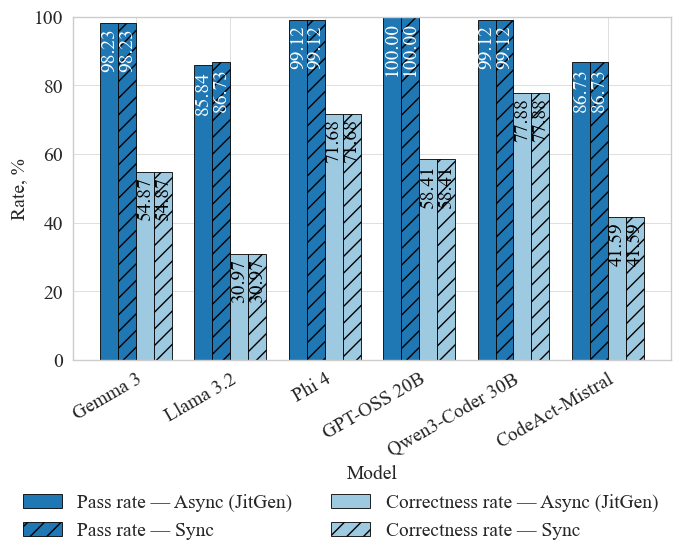

In [12]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 8 — fig-correctness-barplot.png
# Pass rate and correctness rate per model and strategy
# Metric encoded by color (dark/light — grayscale-safe), strategy by hatch
# ══════════════════════════════════════════════════════════════════════
rates = (
    df.groupby(["ModelLabel", "Strategy"])
    .agg(Pass=("ErrorOccurred", lambda x: (1 - x.mean()) * 100),
         Correct=("CorrectOutput", lambda x: x.mean() * 100))
    .reset_index()
)

METRIC_COLORS = {"Pass": "#1f77b4", "Correct": "#9ecae1"}
METRIC_NAMES = {"Pass": "Pass rate", "Correct": "Correctness rate"}
SERIES = [(m, s) for m in ["Pass", "Correct"] for s in STRATEGIES]

fig, ax = new_fig(140)
x = np.arange(len(MODEL_ORDER))
width = 0.19

for i, (metric, strategy) in enumerate(SERIES):
    vals = [
        rates.loc[(rates["ModelLabel"] == m) & (rates["Strategy"] == strategy),
                  metric].values[0]
        for m in MODEL_ORDER
    ]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, color=METRIC_COLORS[metric],
                  hatch=HATCHES[strategy], edgecolor="black", linewidth=0.6,
                  label=f"{METRIC_NAMES[metric]} — {strategy}")
    text_color = "white" if metric == "Pass" else "black"
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v - 1.5, f"{v:.2f}",
                rotation=90, ha="center", va="top", fontsize=14,
                color=text_color)

ax.set_xlabel("Model")
ax.set_ylabel("Rate, %")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha="right", rotation_mode="anchor")

fig.legend(loc="outside lower center", ncols=2, frameon=False)

save_fig(fig, "fig-correctness-barplot.png")
plt.show()

Saved images\fig-error-distribution.png (0.37 MB)


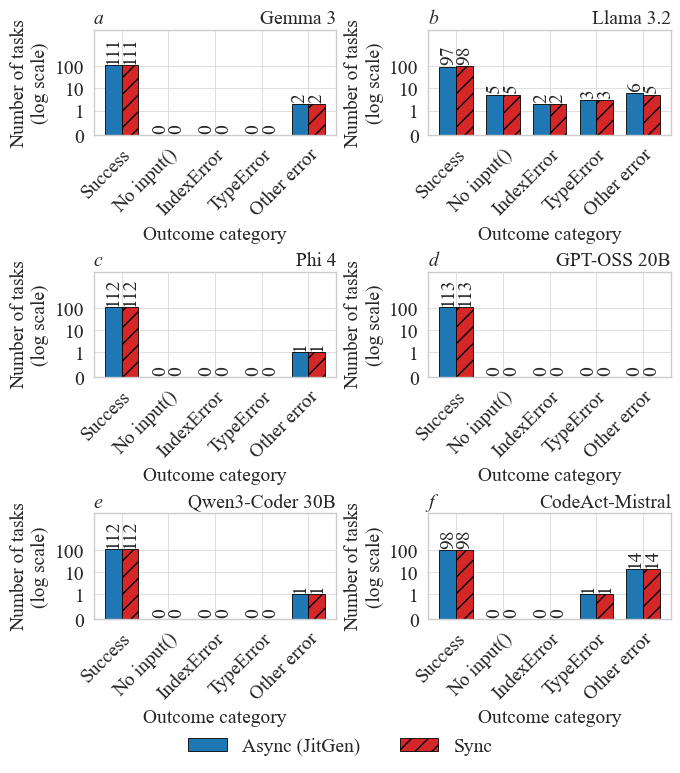

In [13]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 9 — fig-error-distribution.png
# Run outcome counts by category, one model per panel (a–f)
# symlog Y keeps zero-count categories visibly zero; counts annotated
# ══════════════════════════════════════════════════════════════════════
# Display names must match manuscript Table 6 (CSV table keeps original names)
CATEGORY_DISPLAY = {"Disabled input()": "No input()", "Other Error": "Other error"}
df["OutcomeCategory"] = df["ErrorCategory"].replace(CATEGORY_DISPLAY)

CATEGORY_ORDER = ["Success", "No input()", "IndexError", "TypeError", "Other error"]
extra_cats = sorted(set(df["OutcomeCategory"]) - set(CATEGORY_ORDER))
categories = CATEGORY_ORDER + extra_cats

counts = (
    df.groupby(["ModelLabel", "Strategy", "OutcomeCategory"])
    .size()
    .unstack("OutcomeCategory")
    .reindex(columns=categories, fill_value=0)
    .fillna(0)
    .astype(int)
)
y_max = counts.to_numpy().max()

fig, axes = new_fig(195, nrows=3, ncols=2)
x = np.arange(len(categories))
width = 0.36

for ax, letter, model in zip(axes.ravel(), PANEL_LETTERS, MODEL_ORDER):
    for i, strategy in enumerate(STRATEGIES):
        vals = counts.loc[(model, strategy)].values
        offset = (i - 0.5) * width
        ax.bar(x + offset, vals, width, color=PALETTE[strategy],
               hatch=HATCHES[strategy], edgecolor="black", linewidth=0.6)
        for xi, v in zip(x + offset, vals):
            ax.text(xi, v * 1.25 if v > 0 else 0.08, str(v), rotation=90,
                    ha="center", va="bottom", fontsize=14)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_ylim(0, y_max * 40)  # headroom for the vertical count labels
    ax.yaxis.set_major_locator(mticker.FixedLocator([0, 1, 10, 100]))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel("Outcome category")
    ax.set_ylabel("Number of tasks\n(log scale)")
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha="right", rotation_mode="anchor")
    # Panel letter above the axes so it cannot collide with count labels
    ax.text(0.0, 1.02, letter, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14, fontstyle="italic")
    ax.text(1.0, 1.02, model, transform=ax.transAxes,
            ha="right", va="bottom", fontsize=14)

handles = [
    Patch(facecolor=PALETTE[s], hatch=HATCHES[s], edgecolor="black",
          linewidth=0.6, label=s)
    for s in STRATEGIES
]
fig.legend(handles=handles, loc="outside lower center", ncols=2, frameon=False)

save_fig(fig, "fig-error-distribution.png")
plt.show()

Saved images\fig-summary-heatmap.png (0.41 MB)


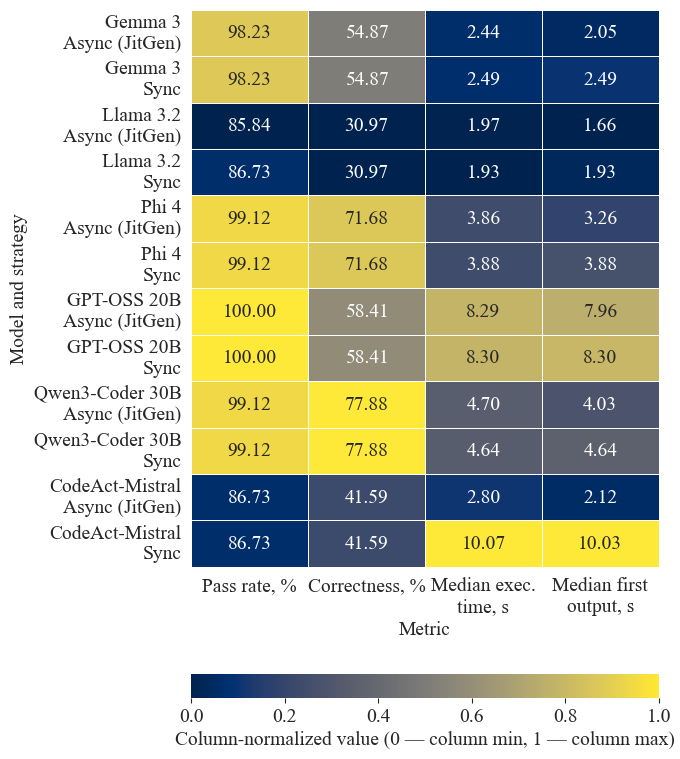

In [14]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 10 — fig-summary-heatmap.png
# Overview of benchmark metrics: rows = model + strategy, cols = metrics
# Color = per-column min–max normalized; raw values annotated in cells
# ══════════════════════════════════════════════════════════════════════
heat_raw = (
    df.groupby(["ModelLabel", "Strategy"])
    .agg(**{
        "Pass rate, %": ("ErrorOccurred", lambda x: (1 - x.mean()) * 100),
        "Correctness, %": ("CorrectOutput", lambda x: x.mean() * 100),
        "Median exec.\ntime, s": ("ExecutionTime", "median"),
        "Median first\noutput, s": ("FirstOutput", "median"),
    })
    .round(2)
    .reindex(pd.MultiIndex.from_product([MODEL_ORDER, STRATEGIES],
                                        names=["ModelLabel", "Strategy"]))
)
heat_raw.index = [f"{m}\n{s}" for m, s in heat_raw.index]

# Per-column min–max normalization for the color scale only
heat_norm = heat_raw.copy()
for col in heat_norm.columns:
    mn, mx = heat_norm[col].min(), heat_norm[col].max()
    heat_norm[col] = (heat_norm[col] - mn) / (mx - mn) if mx > mn else 0.5

fig, ax = new_fig(190)
sns.heatmap(
    heat_norm, annot=heat_raw.values, fmt=".2f",
    cmap="cividis", vmin=0, vmax=1, linewidths=0.5, linecolor="white",
    annot_kws={"fontsize": 14}, ax=ax,
    cbar_kws={
        "orientation": "horizontal",
        "label": "Column-normalized value (0 — column min, 1 — column max)",
        "fraction": 0.05, "pad": 0.06,
    },
)
ax.set_xlabel("Metric")
ax.set_ylabel("Model and strategy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Column-normalized value (0 — column min, 1 — column max)",
               fontsize=14)

save_fig(fig, "fig-summary-heatmap.png")
plt.show()

In [15]:
# ══════════════════════════════════════════════════════════════════════
# SUMMARY — List all generated artifacts
# ══════════════════════════════════════════════════════════════════════
print("=" * 60)
print("GENERATED ARTIFACTS")
print("=" * 60)
print("\nTables (CSV):")
for f in sorted(TABLES_DIR.glob("*.csv")):
    print(f"  {f}")
print("\nTARP figures (PNG, 170 mm wide @ 300 DPI):")
for f in sorted(IMAGES_DIR.glob("fig-*.png")):
    print(f"  {f}")
print(f"\nTotal: {len(list(TABLES_DIR.glob('*.csv')))} tables, "
      f"{len(list(IMAGES_DIR.glob('fig-*.png')))} figures")

GENERATED ARTIFACTS

Tables (CSV):
  tables\error_breakdown.csv
  tables\pass_correctness.csv
  tables\statistical_tests.csv
  tables\summary_statistics.csv

TARP figures (PNG, 170 mm wide @ 300 DPI):
  images\fig-correctness-barplot.png
  images\fig-delta-first-output-boxplot.png
  images\fig-error-distribution.png
  images\fig-execution-time-violin.png
  images\fig-first-output-ecdf.png
  images\fig-first-output-violin.png
  images\fig-speedup-ratio-barplot.png
  images\fig-summary-heatmap.png

Total: 4 tables, 8 figures


In [16]:
# ══════════════════════════════════════════════════════════════════════
# ACCEPTANCE CHECKLIST — TARP physical-format checks on every fig-*.png
#   width  = 170 mm × 300 dpi ≈ 2008 px (±2)
#   height ≤ 200 mm × 300 dpi ≈ 2362 px
#   file size ≤ 5 MB
# ══════════════════════════════════════════════════════════════════════
from PIL import Image

EXPECTED_W = round(170 / 25.4 * DPI)   # 2008
MAX_H = round(200 / 25.4 * DPI)        # 2362
MAX_MB = 5.0

EXPECTED_FIGS = [
    "fig-first-output-violin.png",
    "fig-first-output-ecdf.png",
    "fig-delta-first-output-boxplot.png",
    "fig-execution-time-violin.png",
    "fig-speedup-ratio-barplot.png",
    "fig-correctness-barplot.png",
    "fig-error-distribution.png",
    "fig-summary-heatmap.png",
]

rows = []
for name in EXPECTED_FIGS:
    path = IMAGES_DIR / name
    if not path.exists():
        rows.append({"Figure": name, "Status": "MISSING"})
        continue
    with Image.open(path) as im:
        w, h = im.size
    size_mb = path.stat().st_size / 2**20
    ok = abs(w - EXPECTED_W) <= 2 and h <= MAX_H and size_mb <= MAX_MB
    rows.append({
        "Figure": name, "Width_px": w, "Height_px": h,
        "Size_MB": round(size_mb, 2), "Status": "PASS" if ok else "FAIL",
    })

checklist = pd.DataFrame(rows)
print(checklist.to_string(index=False))
assert (checklist["Status"] == "PASS").all(), "TARP format check failed"
print(f"\nAll {len(EXPECTED_FIGS)} figures pass: width ≈ {EXPECTED_W} px, "
      f"height ≤ {MAX_H} px, size ≤ {MAX_MB} MB")

                            Figure  Width_px  Height_px  Size_MB Status
       fig-first-output-violin.png      2007       1535     0.24   PASS
         fig-first-output-ecdf.png      2007       2125     0.25   PASS
fig-delta-first-output-boxplot.png      2007       1417     0.18   PASS
     fig-execution-time-violin.png      2007       1535     0.25   PASS
     fig-speedup-ratio-barplot.png      2007       1417     0.18   PASS
       fig-correctness-barplot.png      2007       1653     0.26   PASS
        fig-error-distribution.png      2007       2303     0.37   PASS
           fig-summary-heatmap.png      2007       2244     0.41   PASS

All 8 figures pass: width ≈ 2008 px, height ≤ 2362 px, size ≤ 5.0 MB
